In [3]:
!pip install matplotlib
!pip install plotly


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

In [7]:
comments = pd.read_csv(r"C:\Users\rickymht\Documents\SQL practice\Python project\Youtube Case study\UScomments.csv", on_bad_lines = 'skip')

C:\Users\rickymht\AppData\Local\Temp\ipykernel_38772\2869892774.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  comments = pd.read_csv(r"C:\Users\rickymht\Documents\SQL practice\Python project\Youtube Case study\UScomments.csv", on_bad_lines = 'skip')


In [8]:
comments

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
...,...,...,...,...
691395,EoejGgUNmVU,Лучшая,1,0
691396,EoejGgUNmVU,qu'est ce que j'aimerais que tu viennes à Roan...,0,0
691397,EoejGgUNmVU,Ven a mexico! 😍 te amo LP,0,0
691398,EoejGgUNmVU,Islığı yeter...,0,0


In [9]:
comments.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
691395     True
691396     True
691397     True
691398    False
691399     True
Length: 691400, dtype: bool

In [10]:
#To filter out duplicated rows from the dataset and sorts the values on the basis of text in comment_text
comments[comments.duplicated(keep = False)].sort_values('comment_text')

,video_id,comment_text,likes,replies
577043,xEqCt7GZo7M,,0,0
597655,xEqCt7GZo7M,,0,0
561617,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
581888,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
603266,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
...,...,...,...,...
563768,CX4KuIBmnjI,NaN,0,0
584612,CX4KuIBmnjI,NaN,0,0
605039,CX4KuIBmnjI,NaN,0,0
615625,5qlSfNVp3fU,NaN,0,0


In [11]:
#To drop duplicate rows from the data and save the changes to dataset
comments = comments.drop_duplicates()


In [12]:
#To check the null values in the dataset
comments.isnull()

,video_id,comment_text,likes,replies
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
691359,False,False,False,False
691366,False,False,False,False
691392,False,False,False,False
691393,False,False,False,False


In [16]:
#As the data is not clear we will sum the number of null values for each variable
comments.isnull().sum()

video_id        0
comment_text    0
likes           0
replies         0
dtype: int64

In [17]:
comments.dropna(inplace = True)

C:\Users\rickymht\AppData\Local\Temp\ipykernel_38772\1419364384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comments.dropna(inplace = True)


In [18]:
#The code shows we have dropped the rows where the value was null
comments.isnull().sum()

video_id        0
comment_text    0
likes           0
replies         0
dtype: int64

### 2. Sentiment Analysis

In [19]:
!pip install nltk


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import nltk

In [21]:
#lexicon is a built in list of words with sentiment scores
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rickymht\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [22]:
'''Calling that specific import line tells Python to look inside the nltk library, go into its sentiment folder, find a specific tool called 
SentimentIntensityAnalyzer, and bring it into notebook so it can be used.'''
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [23]:
sia = SentimentIntensityAnalyzer()

In [24]:
comments['comment_text']

0                         Logan Paul it's yo big day ‼️‼️‼️
1         I've been following you from the start of your...
2                        Say hi to Kong and maverick for me
3                                       MY FAN . attendance
4                                                trending 😉
                                ...                        
691359       Lost on you ! 😍\nOH My God I love this song !😭
691366                                        I  LOVE  LP❤️
691392                                *L O S T  O N  Y O U*
691393                                                   <3
691398                                      Islığı yeter...
Name: comment_text, Length: 478691, dtype: object

In [25]:
#defining a function to analyse the sentiments from comment
def analyze_comment_sentiment(comment):
    compound = sia.polarity_scores(comment)['compound']

    if compound > 0.05:
        label = 'Positive'
        insight = 'The comment expresses positive emotion or approval'

    elif compound < -0.05:
        label = 'Negative'
        insight = 'The comment shows dis-satisfaction or negative emotion'

    else:
        label = 'Neutral'
        insight = 'The comment is emotionally neutral'

    return{
        'label' : label,
        'score' : compound,
        'insight' : insight }
        

In [26]:
analyze_comment_sentiment("Worst edited video ever seen")

{'label': 'Negative',
 'score': -0.6249,
 'insight': 'The comment shows dis-satisfaction or negative emotion'}

### 3. Emoji's Analysis

We have around 400k text comment data and to simplfy our analysis we will extract only the emoji from our comments and try to understand the viewer response

In [34]:
!pip install emoji



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import emoji

In [36]:
# For reference to get the first 25 comments from the data 
comments['comment_text'].head(25)

0                     Logan Paul it's yo big day ‼️‼️‼️
1     I've been following you from the start of your...
2                    Say hi to Kong and maverick for me
3                                   MY FAN . attendance
4                                            trending 😉
5                               #1 on trending AYYEEEEE
6                                  The end though 😭👍🏻❤️
7                                  #1 trending!!!!!!!!!
8                           Happy one year vlogaversary
9     You and your shit brother may have single hand...
10               There should be a mini Logan Paul too!
11    Dear Logan, I really wanna get your Merch but ...
12    Honestly Evan is so annoying. Like its not fun...
13                     Casey is still better then logan
14        aw geez rick this guy is the face of YouTube.
15                         He happy cause he in a movie
16    Ayyyyoooo Logang what up .  This was a hard vl...
17    Bro y didnt u give merch to johannes he is

In [37]:
# To check the number of different emojis in the library
total_emojis = len(emoji.EMOJI_DATA)
print(f'My Python library knows about {total_emojis} different emojis')

My Python library knows about 5225 different emojis


In [38]:
# trying to extract the emoji from a text
comment = 'trending 😉'

emoji_list = [] #a blank list that will store the lists of all the emojis  extracted from comments

for char in comment:
    if char in emoji.EMOJI_DATA:
        emoji_list.append(char)

In [39]:
emoji_list

['😉']

In [40]:
# to extract data from comments dataset

all_emoji = []

for comment in comments['comment_text'].dropna(): # to extract the comments and drop any missing values
    for char in comment:
        if char in emoji.EMOJI_DATA:
            all_emoji.append(char)
all_emoji[0:10] #to check only the first 10 values

['‼', '‼', '‼', '😉', '😭', '👍', '🏻', '❤', '😍', '💋']

In [41]:
len(all_emoji) #number of different emojis in the extracted data

213868

In [42]:
from collections import Counter

In [43]:
emoji_count = Counter(all_emoji).most_common(10)
emoji_count

[('😂', 27287),
 ('❤', 22180),
 ('😍', 22145),
 ('🔥', 6288),
 ('😭', 6155),
 ('💖', 4242),
 ('😘', 4174),
 ('👏', 4005),
 ('👍', 3789),
 ('💕', 3731)]

In [44]:
emojis = [emoji for emoji, count in emoji_count] #it gives out the list of top 10 emoji
emojis

['😂', '❤', '😍', '🔥', '😭', '💖', '😘', '👏', '👍', '💕']

In [45]:
count = [count for emoji, count in emoji_count]
count

[27287, 22180, 22145, 6288, 6155, 4242, 4174, 4005, 3789, 3731]

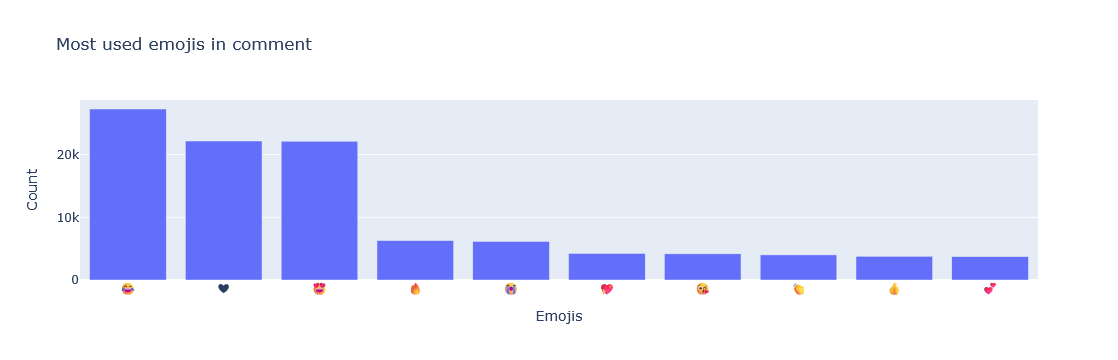

In [46]:
# bar plot to visualize the count per emoji
px.bar(x = emojis, y = count, title = 'Most used emojis in comment', 
       labels = {'x' : 'Emojis',
            'y': 'Count'})

### 4. Collect entire data

In [48]:
import os

In [50]:
files = os.listdir(r'C:\Users\rickymht\Documents\SQL practice\Python project\Youtube Case study\additional_data')

In [52]:
#Other country data
files

['CAvideos.csv',
 'CA_category_id.json',
 'DEvideos.csv',
 'DE_category_id.json',
 'FRvideos.csv',
 'FR_category_id.json',
 'GBvideos.csv',
 'GB_category_id.json',
 'INvideos.csv',
 'IN_category_id.json',
 'JPvideos.csv',
 'JP_category_id.json',
 'KRvideos.csv',
 'KR_category_id.json',
 'MXvideos.csv',
 'MX_category_id.json',
 'RUvideos.csv',
 'RU_category_id.json',
 'USvideos.csv',
 'US_category_id.json']

In [55]:
files_csv = [file for file in files if '.csv' in file]

In [56]:
files_csv

['CAvideos.csv',
 'DEvideos.csv',
 'FRvideos.csv',
 'GBvideos.csv',
 'INvideos.csv',
 'JPvideos.csv',
 'KRvideos.csv',
 'MXvideos.csv',
 'RUvideos.csv',
 'USvideos.csv']

In [59]:
full_df = pd.DataFrame()

path = r'C:\Users\rickymht\Documents\SQL practice\Python project\Youtube Case study\additional_data'

for file in files_csv:
    current_df = pd.read_csv(path+'/'+file, encoding = 'iso=8859-1', on_bad_lines = 'skip')
    full_df = pd.concat([current_df, full_df], ignore_index = True)

In [60]:
full_df.shape

(375942, 16)

In [62]:
# to view the top 3 rows from the dataframe
full_df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...


In [63]:
# to view all the columns from the dataframe
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

### 5. How to export your data into (CSV, JSON, DB)

In [66]:
# wherever we have boolean false, the row in not duplicate
full_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
375937    False
375938    False
375939    False
375940    False
375941    False
Length: 375942, dtype: bool

In [67]:
full_df[full_df.duplicated()].shape

(36417, 16)

In [68]:
full_df = full_df.drop_duplicates()

In [70]:
full_df.shape

(339525, 16)

In [71]:
# to export data in CSV
full_df[0:5000].to_csv(r'C:\Users\rickymht\Documents\SQL practice\Python project\Export data\youtube_data.csv', index = False)

### 6. Which category dominates Youtube ?

In [73]:
full_df.dtypes
#trending_date data type should be datae time rather than a object (which is incorrect)

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object

In [74]:
full_df['trending_date']

0         17.14.11
1         17.14.11
2         17.14.11
3         17.14.11
4         17.14.11
            ...   
375937    18.14.06
375938    18.14.06
375939    18.14.06
375940    18.14.06
375941    18.14.06
Name: trending_date, Length: 339525, dtype: object

In [77]:
full_df['trending_date'] = pd.to_datetime(full_df['trending_date'], format = '%y.%d.%m')

C:\Users\rickymht\AppData\Local\Temp\ipykernel_38772\85636546.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['trending_date'] = pd.to_datetime(full_df['trending_date'], format = '%y.%d.%m')


In [79]:
full_df.dtypes
#the valued of trending date has changed to date time now

video_id                          object
trending_date             datetime64[ns]
title                             object
channel_title                     object
category_id                        int64
publish_time                      object
tags                              object
views                              int64
likes                              int64
dislikes                           int64
comment_count                      int64
thumbnail_link                    object
comments_disabled                   bool
ratings_disabled                    bool
video_error_or_removed              bool
description                       object
dtype: object

In the data type we see we do not have any category names column but only a category ID. To get the names of the category we will import one of the files which has the category code as well as the category name

In [80]:
import json

In [82]:
path = r'C:\Users\rickymht\Documents\SQL practice\Python project\Youtube Case study\additional_data\US_category_id.json'

In [85]:
with open(path, 'r', encoding = 'utf-8') as f:
    data = json.load(f)

In [86]:
data

{'kind': 'youtube#videoCategoryListResponse',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJvJAAShlR6hM"',
 'items': [{'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
   'id': '1',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Film & Animation',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45ZTFR3a3NyTA"',
   'id': '2',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Autos & Vehicles',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxbknKFVe5Lmg"',
   'id': '10',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Music',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-oBJavSGkfDI"',
   'id': '15',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdnt

In [87]:
data['items'][0]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [88]:
# to fetch the category name
data['items'][0]['snippet']['title']

'Film & Animation'

In [92]:
# to create a category dictionary
cat_dict = {}

for item in data['items']:
    cat_dict[int(item['id'])] = item['snippet']['title']

In [93]:
cat_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [94]:
full_df['category_id']

0         22
1         24
2         23
3         24
4         24
          ..
375937    24
375938    24
375939    20
375940    25
375941    24
Name: category_id, Length: 339525, dtype: int64

In [97]:
#mapping the category id, with the category dictionary 
full_df['category_name'] = full_df['category_id'].map(cat_dict)

C:\Users\rickymht\AppData\Local\Temp\ipykernel_38772\1663408134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['category_name'] = full_df['category_id'].map(cat_dict)


In [98]:
full_df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy


In [103]:
#to pivot the data on views for each category for the particular data 
pivot_df = full_df.groupby(['trending_date', 'category_name'])['views'].sum().unstack(fill_value = 0)
pivot_df

category_name,Autos & Vehicles,Comedy,Education,Entertainment,Film & Animation,Gaming,Howto & Style,Movies,Music,News & Politics,Nonprofits & Activism,People & Blogs,Pets & Animals,Science & Technology,Shows,Sports,Trailers,Travel & Events
trending_date,,,,,,,,,,,,,,,,,,
2017-11-14,5449767,92798793,8625525,233134424,59824388,20788680,39692396,0,522096451,22893805,1397585,69741490,3427634,19628265,1689318,34161599,0,1424022
2017-11-15,8050486,89048129,7072457,200761218,73620337,18302875,47173790,0,363498984,19512569,5363406,68342887,1684139,44572576,2456621,40823955,0,1487868
2017-11-16,7358437,82066922,7296205,215075485,78182533,18411174,36334035,0,336201790,21519797,4584043,47542853,2609618,39281789,1019265,46353999,0,2066936
2017-11-17,6436997,81766773,9328728,231929119,50794195,10147876,34707221,0,357949721,25304189,1377828,48916714,2068139,48763394,2433230,41649023,0,1001796
2017-11-18,7098844,80400958,8837341,217196554,64075205,10738066,29769264,0,369823307,26600320,2859005,45943293,4302877,77863217,3520947,33424799,0,1487049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-06-10,3419469,92834235,7405034,541526503,120104266,70525231,63597826,0,1388065416,50320845,2267573,156067902,16377474,38192009,1764569,71436390,0,1855303
2018-06-11,4911969,93551035,10338600,505373442,119098102,74941508,62355833,0,1297630273,32512659,2739846,126699590,17112106,38183326,2122065,77764246,0,2108882
2018-06-12,5126438,109037786,9841181,482032248,135940594,108525939,54252824,0,943951258,35845162,3237080,128605502,15477174,30930795,2436709,57287168,0,2287951


In [105]:
area_chart = px.area(
    data_frame = pivot_df, 
    x = pivot_df.index, 
    y = pivot_df.columns, 
    title = 'Trending momentum over time by category'
)

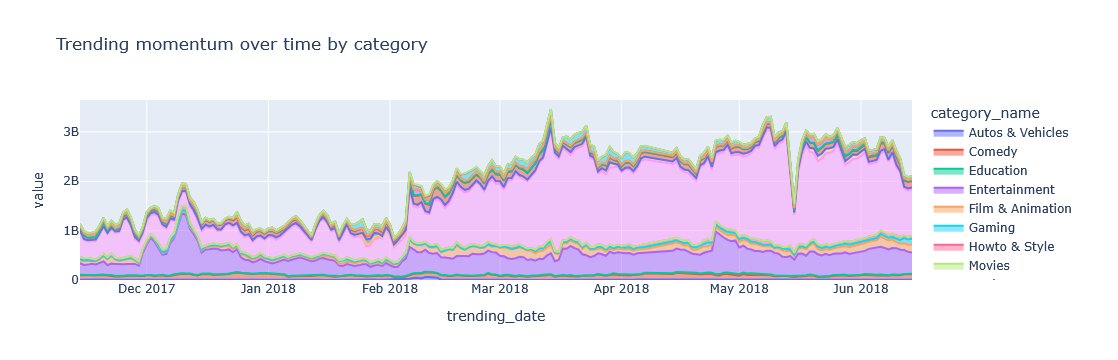

In [106]:
area_chart

In [108]:
# as there are multiple categories stacked in the graph we will filter out the first top 6 categories 

top_categories = full_df.groupby(['category_name'])['views'].sum().nlargest(6).index
top_categories

Index(['Music', 'Entertainment', 'Film & Animation', 'People & Blogs',
       'Comedy', 'Sports'],
      dtype='object', name='category_name')

In [111]:
filtered_df = pivot_df[top_categories]
filtered_df

category_name,Music,Entertainment,Film & Animation,People & Blogs,Comedy,Sports
trending_date,,,,,,
2017-11-14,522096451,233134424,59824388,69741490,92798793,34161599
2017-11-15,363498984,200761218,73620337,68342887,89048129,40823955
2017-11-16,336201790,215075485,78182533,47542853,82066922,46353999
2017-11-17,357949721,231929119,50794195,48916714,81766773,41649023
2017-11-18,369823307,217196554,64075205,45943293,80400958,33424799
...,...,...,...,...,...,...
2018-06-10,1388065416,541526503,120104266,156067902,92834235,71436390
2018-06-11,1297630273,505373442,119098102,126699590,93551035,77764246
2018-06-12,943951258,482032248,135940594,128605502,109037786,57287168


In [112]:
area_chart = px.area(
    data_frame = pivot_df, 
    x = filtered_df.index, 
    y = filtered_df.columns, 
    title = 'Trending momentum over time by category'
)

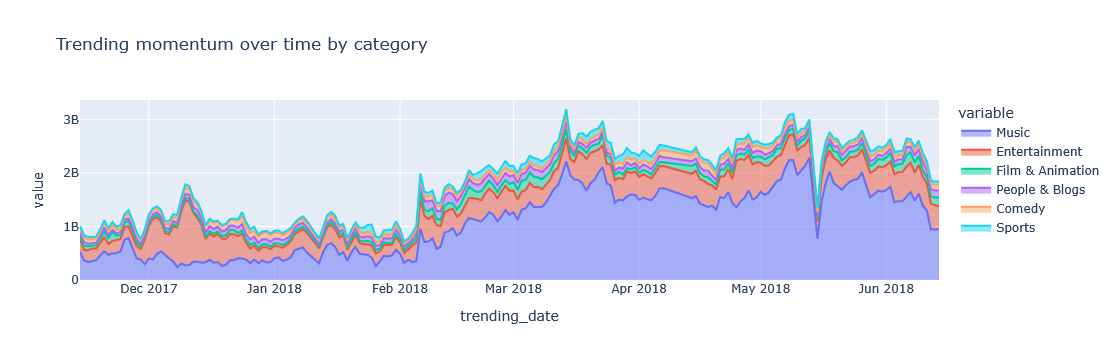

In [113]:
area_chart

### 7. Do viral videos actually get engagement ?


In [116]:
full_df.columns
#we don't have a column for engagment rate

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name'],
      dtype='object')

In [119]:
#engagement rate = [Interaction (comments + likes)]/views
full_df['engagement_rate'] = (full_df['likes'] + full_df['comment_count']) / full_df['views']

C:\Users\rickymht\AppData\Local\Temp\ipykernel_38772\1734558016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['engagement_rate'] = (full_df['likes'] + full_df['comment_count']) / full_df['views']


In [123]:
bubble_plot = px.scatter(
    full_df, 
    x = 'views', 
    y = 'engagement_rate',
    size = 'comment_count', 
    color = 'category_name',
    hover_name = 'title',
    title = 'Engagement bubble map: Views Vs Engagement rate',
    size_max = 60
)

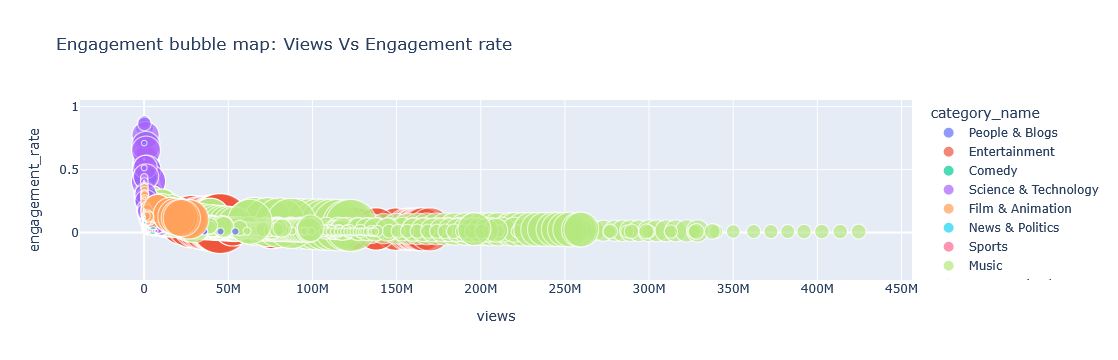

In [124]:
bubble_plot

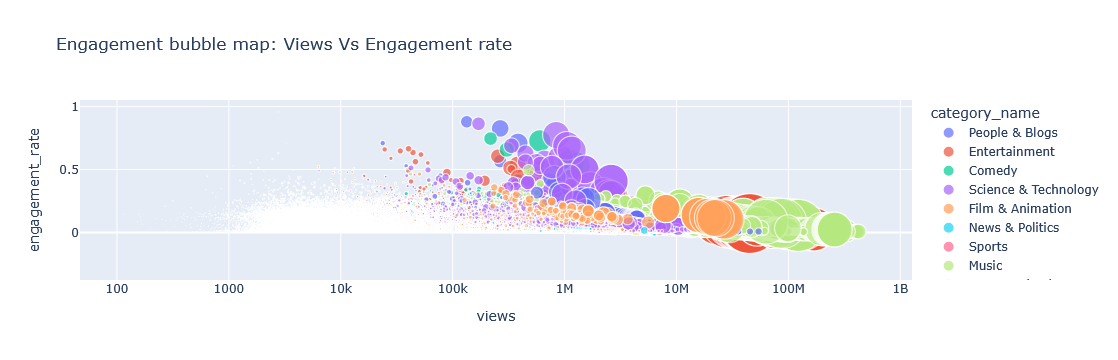

In [125]:
bubble_plot.update_xaxes(type = 'log')

### 8. Views Vs Engagement: Inside Youtube's algorithim

In [126]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name',
       'engagement_rate'],
      dtype='object')

In [130]:
category_metrics = full_df.groupby('category_name').agg(
                                    total_views = ('views', 'sum'),
                                    avg_engagement_efficiency = ('engagement_rate', 'mean'),
                                    video_count = ('video_id', 'count')).reset_index()

In [131]:
category_metrics

,category_name,total_views,avg_engagement_efficiency,video_count
0,Autos & Vehicles,1514202384,0.049873,4596
1,Comedy,18341009925,0.058413,24024
2,Education,2485052061,0.057669,7396
3,Entertainment,85162066718,0.036217,97365
4,Film & Animation,20397383805,0.033448,18329
5,Gaming,6216418800,0.057708,10433
6,Howto & Style,8271658225,0.062121,17549
7,Movies,33047793,0.016044,22
8,Music,220389615568,0.051929,36990
9,News & Politics,8817653917,0.028820,34599


In [141]:
treemap = px.treemap(
    category_metrics, 
    path = ['category_name'],
    values = 'total_views',
    color = 'avg_engagement_efficiency',
    color_continuous_scale = 'RdYlGn',
    title = 'Category attention share with engagement efficiency overlay', 
    hover_data = {
        'total_views': ':, .0f',
        'avg_engagement_efficiency': ':, .3f',
        'video_count': True
    }
)


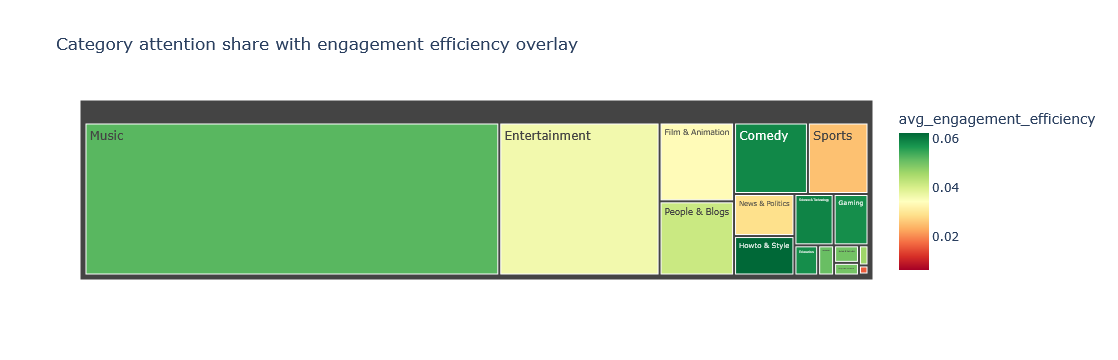

In [142]:
treemap

### 9. Is the audience actually engaged ?


In [143]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name',
       'engagement_rate'],
      dtype='object')

In [144]:
full_df['engagement_rate'].describe()

count    339525.000000
mean          0.042103
std           0.043971
min           0.000000
25%           0.010395
50%           0.027453
75%           0.060261
max           0.957256
Name: engagement_rate, dtype: float64

In [148]:
category_engagement_stats = full_df.groupby('category_name')['engagement_rate'].describe()
category_engagement_stats.sort_values('mean', ascending = False)

,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
Howto & Style,17549.0,0.062121,0.042688,0.000000,0.032948,0.052991,0.082680,0.709778
Science & Technology,7350.0,0.058860,0.053710,0.000000,0.024923,0.047330,0.077522,0.774282
Comedy,24024.0,0.058413,0.046692,0.000000,0.022036,0.048903,0.082108,0.746056
Gaming,10433.0,0.057708,0.048587,0.000000,0.022935,0.048472,0.078039,0.863608
Education,7396.0,0.057669,0.042375,0.000000,0.028697,0.050298,0.077079,0.445312
Music,36990.0,0.051929,0.045435,0.000000,0.021012,0.038634,0.067957,0.506464
Pets & Animals,4215.0,0.050707,0.039806,0.000000,0.023875,0.040444,0.066759,0.330806
Autos & Vehicles,4596.0,0.049873,0.035542,0.000000,0.024870,0.045179,0.068422,0.234820
Nonprofits & Activism,2722.0,0.049619,0.058793,0.000000,0.009192,0.023070,0.074042,0.704366


In [151]:
box = px.box(full_df, 
       x = 'category_name',
       y = 'engagement_rate',
       color = 'category_name',
       title = 'Audience engagement by category')

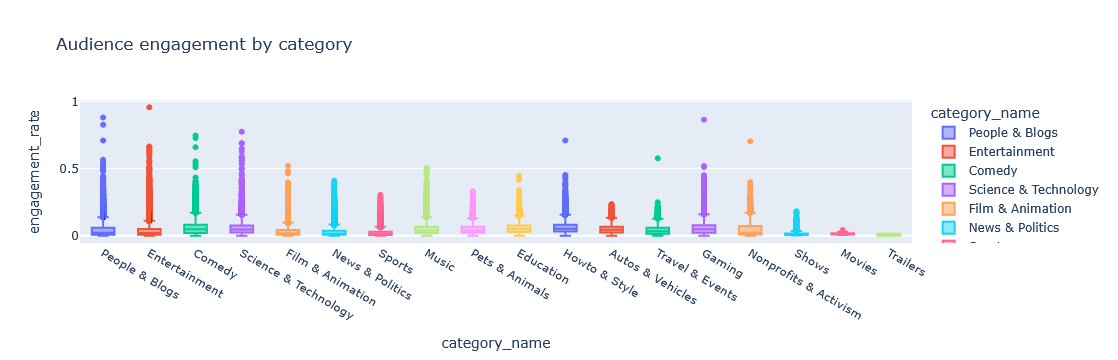

In [152]:
box